# ☕ EDA — Coffee Quality Classification
### Proyecto Grupal — Clasificación de Calidad de Café

---

## 📖 ¿Qué es un EDA y para qué sirve?

El **Análisis Exploratorio de Datos (EDA)** es el primer paso de todo proyecto de Machine Learning.  
Antes de entrenar cualquier modelo, necesitamos **entender** los datos:
- ¿Qué hay en el dataset?
- ¿Los datos están limpios o tienen errores?
- ¿Qué variables son importantes?
- ¿Hay patrones o relaciones entre variables?

**Analogía:** El EDA es como leer el manual de instrucciones antes de montar un mueble. Puedes saltártelo, pero luego te sobran tornillos.

---

## 🗺️ Hoja de Ruta del Notebook

| Bloque | Qué vamos a hacer |
|--------|-------------------|
| **0** | Importar librerías y cargar datos |
| **1** | Primera inspección del dataset |
| **2** | Análisis de valores nulos |
| **3** | Crear la variable objetivo (target) |
| **4** | Análisis de variables numéricas (sensoriales) |
| **5** | Análisis de variables categóricas (origen, proceso) |
| **6** | Correlaciones entre variables |
| **7** | Detección de outliers |
| **8** | Conclusiones y próximos pasos |

---

> ⚠️ **Importante:** Ejecuta las celdas en orden, de arriba a abajo. Cada celda depende de la anterior.

---
## 📦 BLOQUE 0 — Importar librerías y cargar el dataset

**¿Qué son las librerías?**  
Son colecciones de funciones ya escritas por otros que podemos reutilizar.  
- `pandas` → manipular tablas de datos  
- `numpy` → cálculos matemáticos  
- `matplotlib` y `seaborn` → crear gráficos  
- `warnings` → ocultar avisos que no nos interesan

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore') # Para que el notebook se vea limpio

In [10]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
# 📌 ACCIÓN: Cambia la ruta al lugar donde tienes guardado el CSV
# Descarga el dataset desde: https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi
#La ruta no modificarla. Y poner el mismo nombre todos.

df = pd.read_csv('../data/raw/coffee_quality.csv')

print(f'✅ Dataset cargado correctamente')
print(f'📊 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Dataset cargado correctamente
📊 Dimensiones: 207 filas x 41 columnas


---
## 🔍 BLOQUE 1 — Primera inspección del dataset

**Objetivo:** Entender qué hay dentro del dataset sin entrar en detalles todavía.  
Es como abrir una caja y ver qué hay dentro antes de sacar nada.

**Preguntas que vamos a responder:**
- ¿Cuántas filas y columnas tiene?
- ¿Qué significa cada columna?
- ¿Qué tipo de dato tiene cada columna (número, texto, fecha)?

In [11]:
display(df.head())

,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


In [12]:
# Información general del dataset
# 'object' = texto | 'float64/int64' = número
print('ℹ️ Información del dataset:')
df.info()

ℹ️ Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             207 non-null    int64  
 1   ID                     207 non-null    int64  
 2   Country of Origin      207 non-null    str    
 3   Farm Name              205 non-null    str    
 4   Lot Number             206 non-null    str    
 5   Mill                   204 non-null    str    
 6   ICO Number             75 non-null     str    
 7   Company                207 non-null    str    
 8   Altitude               206 non-null    str    
 9   Region                 205 non-null    str    
 10  Producer               206 non-null    str    
 11  Number of Bags         207 non-null    int64  
 12  Bag Weight             207 non-null    str    
 13  In-Country Partner     207 non-null    str    
 14  Harvest Year           207 non-null    st

In [13]:
df.describe()

,Unnamed: 0,ID,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Category Two Defects
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.00000,207.000000,207.000000,207.000000,207.0,207.0,207.000000,207.0,207.000000,207.000000,207.000000,207.000000,207.000000
mean,103.000000,103.000000,155.449275,7.721063,7.744734,7.599758,7.69029,7.640918,7.644058,9.990338,10.0,10.0,7.676812,0.0,83.706570,10.735266,0.135266,0.690821,2.251208
std,59.899917,59.899917,244.484868,0.287626,0.279613,0.275911,0.25951,0.233499,0.256299,0.103306,0.0,0.0,0.306359,0.0,1.730417,1.247468,0.592070,1.686918,2.950183
min,0.000000,0.000000,1.000000,6.500000,6.750000,6.670000,6.83000,6.830000,6.670000,8.670000,10.0,10.0,6.670000,0.0,78.000000,0.000000,0.000000,0.000000,0.000000
25%,51.500000,51.500000,1.000000,7.580000,7.580000,7.420000,7.50000,7.500000,7.500000,10.000000,10.0,10.0,7.500000,0.0,82.580000,10.100000,0.000000,0.000000,0.000000
50%,103.000000,103.000000,14.000000,7.670000,7.750000,7.580000,7.67000,7.670000,7.670000,10.000000,10.0,10.0,7.670000,0.0,83.750000,10.800000,0.000000,0.000000,1.000000
75%,154.500000,154.500000,275.000000,7.920000,7.920000,7.750000,7.87500,7.750000,7.790000,10.000000,10.0,10.0,7.920000,0.0,84.830000,11.500000,0.000000,1.000000,3.000000
max,206.000000,206.000000,2240.000000,8.580000,8.500000,8.420000,8.58000,8.250000,8.420000,10.000000,10.0,10.0,8.580000,0.0,89.330000,13.500000,5.000000,12.000000,16.000000


In [14]:
df.columns.tolist()

['Unnamed: 0',
 'ID',
 'Country of Origin',
 'Farm Name',
 'Lot Number',
 'Mill',
 'ICO Number',
 'Company',
 'Altitude',
 'Region',
 'Producer',
 'Number of Bags',
 'Bag Weight',
 'In-Country Partner',
 'Harvest Year',
 'Grading Date',
 'Owner',
 'Variety',
 'Status',
 'Processing Method',
 'Aroma',
 'Flavor',
 'Aftertaste',
 'Acidity',
 'Body',
 'Balance',
 'Uniformity',
 'Clean Cup',
 'Sweetness',
 'Overall',
 'Defects',
 'Total Cup Points',
 'Moisture Percentage',
 'Category One Defects',
 'Quakers',
 'Color',
 'Category Two Defects',
 'Expiration',
 'Certification Body',
 'Certification Address',
 'Certification Contact']

---
## 🕳️ BLOQUE 2 — Análisis de valores nulos

**¿Qué es un valor nulo?**  
Un valor nulo (NaN = Not a Number) es una celda vacía en nuestros datos.  
Ocurre cuando la información no estaba disponible o no se registró.

**¿Por qué importa?**  
Los modelos de ML no pueden trabajar con valores vacíos. Tenemos que decidir qué hacer con ellos:  
- **Eliminar** la fila o columna  
- **Rellenar** con un valor (media, mediana, moda)

**Regla general:**  
- Si una columna tiene `> 40% nulos` → considerar eliminarla  
- Si tiene `< 40% nulos` → rellenar (imputar)

In [15]:
# Sumamos todos los valores que son True para la condición "is null"
nulos = df.isnull().sum()
# Solo mostramos las columnas que tengan al menos un nulo para no saturar la pantalla
print("Columnas con valores nulos:")
print(nulos[nulos > 0])

Columnas con valores nulos:
Farm Name              2
Lot Number             1
Mill                   3
ICO Number           132
Altitude               1
Region                 2
Producer               1
Variety                6
Processing Method      5
dtype: int64


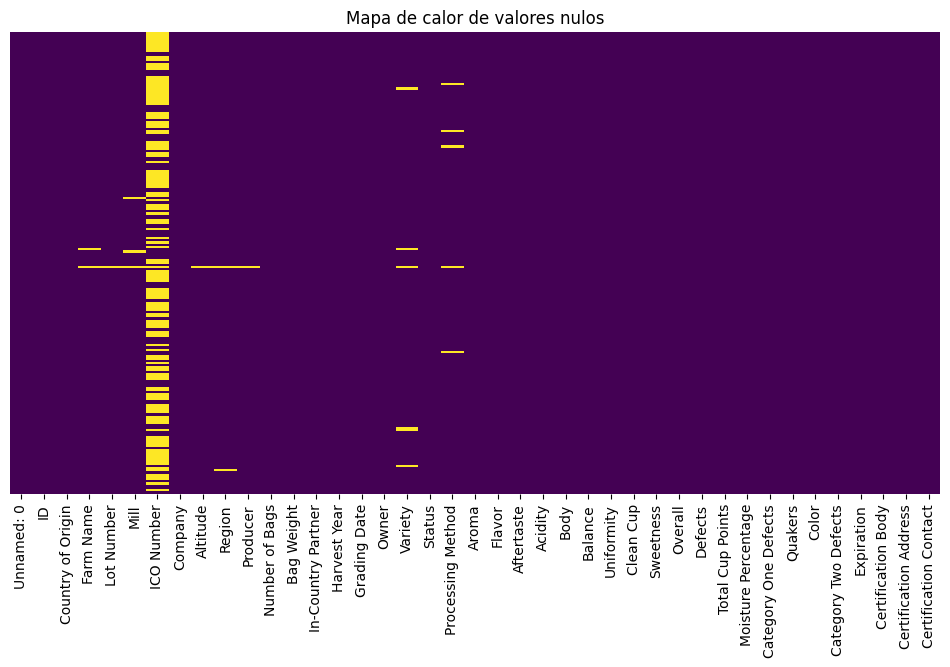

In [16]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

In [17]:
# ─── LIMPIEZA PROFESIONAL ─────────────────────────────────────────

cols_ruido_total = [
    # Metadatos e identificadores
    'Unnamed: 0', 'ID', 'ICO Number', 'Owner', 'Lot Number', 'Mill', 'Company', 
    'Farm Name', 'Region', 'Producer', 'In-Country Partner',
    
    # Datos administrativos y fechas
    'Status', 'Grading Date', 'Expiration', 'Certification Body', 
    'Certification Address', 'Certification Contact', 'Harvest Year',
    
    # Logística
    'Number of Bags', 'Bag Weight',
    
    # Evitar "trampas" (Data Leakage)
    'Overall' 
]

# Eliminamos y limpiamos nulos
df = df.drop(columns=cols_ruido_total, errors='ignore')
df = df.dropna()

print(f"✅ Limpieza Pro realizada.")
print(f"📊 Nos quedan {df.shape[1]} columnas clave (Origen + Sensoriales + Técnicas).")
print(f"📉 Filas resultantes: {df.shape[0]}")

df.describe()

✅ Limpieza Pro realizada.
📊 Nos quedan 20 columnas clave (Origen + Sensoriales + Técnicas).
📉 Filas resultantes: 197


,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Category Two Defects
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.0,197.0,197.0,197.000000,197.000000,197.000000,197.000000,197.000000
mean,7.720406,7.746142,7.600558,7.688528,7.642944,7.645888,9.989848,10.0,10.0,0.0,83.709848,10.698985,0.126904,0.690355,2.263959
std,0.291451,0.280206,0.277807,0.258832,0.233753,0.258036,0.105885,0.0,0.0,0.0,1.739459,1.257954,0.588267,1.714452,2.969465
min,6.500000,6.750000,6.670000,6.830000,6.830000,6.670000,8.670000,10.0,10.0,0.0,78.000000,0.000000,0.000000,0.000000,0.000000
25%,7.580000,7.580000,7.420000,7.500000,7.500000,7.500000,10.000000,10.0,10.0,0.0,82.580000,10.000000,0.000000,0.000000,0.000000
50%,7.670000,7.750000,7.580000,7.670000,7.670000,7.670000,10.000000,10.0,10.0,0.0,83.750000,10.800000,0.000000,0.000000,1.000000
75%,7.920000,7.920000,7.750000,7.830000,7.750000,7.750000,10.000000,10.0,10.0,0.0,84.830000,11.500000,0.000000,1.000000,3.000000
max,8.580000,8.500000,8.420000,8.580000,8.250000,8.420000,10.000000,10.0,10.0,0.0,89.330000,13.500000,5.000000,12.000000,16.000000


---
## 🎯 BLOQUE 3 — Crear la variable objetivo (TARGET)

**¿Qué es el target?**  
Es la variable que queremos predecir. En nuestro caso, si un lote de café es **Specialty** o **No Specialty**.

**¿Cómo lo creamos?**  
Usamos el estándar oficial de la **Specialty Coffee Association (SCA)**:  
- `Total Cup Points >= 82.5` → **Specialty** (calidad premium)  
- `Total Cup Points < 82.5` → **No Specialty** (calidad estándar)

**⚠️ MUY IMPORTANTE:**  
Después de crear el target, debemos **eliminar `Total.Cup.Points` del dataset**.  
Si no lo hacemos, el modelo va a hacer trampa (data leakage) porque el target viene directamente de esa columna.

In [18]:
# Definimos el umbral de la SCA que sugirió el SM
UMBRAL_SPECIALTY = 82.5

# Creamos la columna 'target': 1 si es Specialty, 0 si no lo es
df['is_specialty'] = (df['Total Cup Points'] >= UMBRAL_SPECIALTY).astype(int)

print("✅ Variable objetivo 'is_specialty' creada.")

✅ Variable objetivo 'is_specialty' creada.


Distribución del target (0 = No Specialty, 1 = Specialty):
is_specialty
1    156
0     41
Name: count, dtype: int64


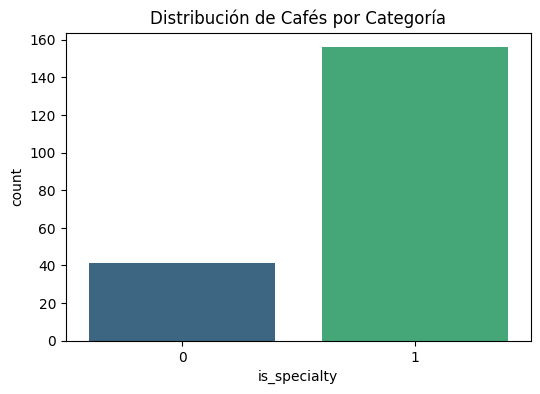


✅ Columna 'Total Cup Points' eliminada para evitar trampas del modelo.


In [19]:
# 1. Miramos cuántos hay de cada uno
print("Distribución del target (0 = No Specialty, 1 = Specialty):")
print(df['is_specialty'].value_counts())

# 2. Graficamos para el informe
plt.figure(figsize=(6, 4))
sns.countplot(x='is_specialty', data=df, palette='viridis')
plt.title('Distribución de Cafés por Categoría')
plt.show()

# 3. ⚠️ ¡MUY IMPORTANTE!: Eliminamos 'Total Cup Points' para evitar el "Data Leakage"
df = df.drop(columns=['Total Cup Points'])

print("\n✅ Columna 'Total Cup Points' eliminada para evitar trampas del modelo.")

---
## 📊 BLOQUE 4 — Análisis de variables numéricas (sensoriales)

**Objetivo:** Entender cómo se distribuyen las puntuaciones sensoriales y si hay diferencias entre cafés Specialty y No Specialty.

**¿Qué vamos a ver?**
- **Histograma:** Distribución de cada puntuación ¿es normal? ¿está sesgada?
- **Boxplot:** Comparación entre categorías de calidad
- **Violinplot:** Distribución completa por categoría

In [20]:
# Estas son las variables que un catador (Q-Grader) puntúa del 0 al 10
sensoriales = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 
               'Balance', 'Uniformity', 'Clean Cup', 'Sweetness']


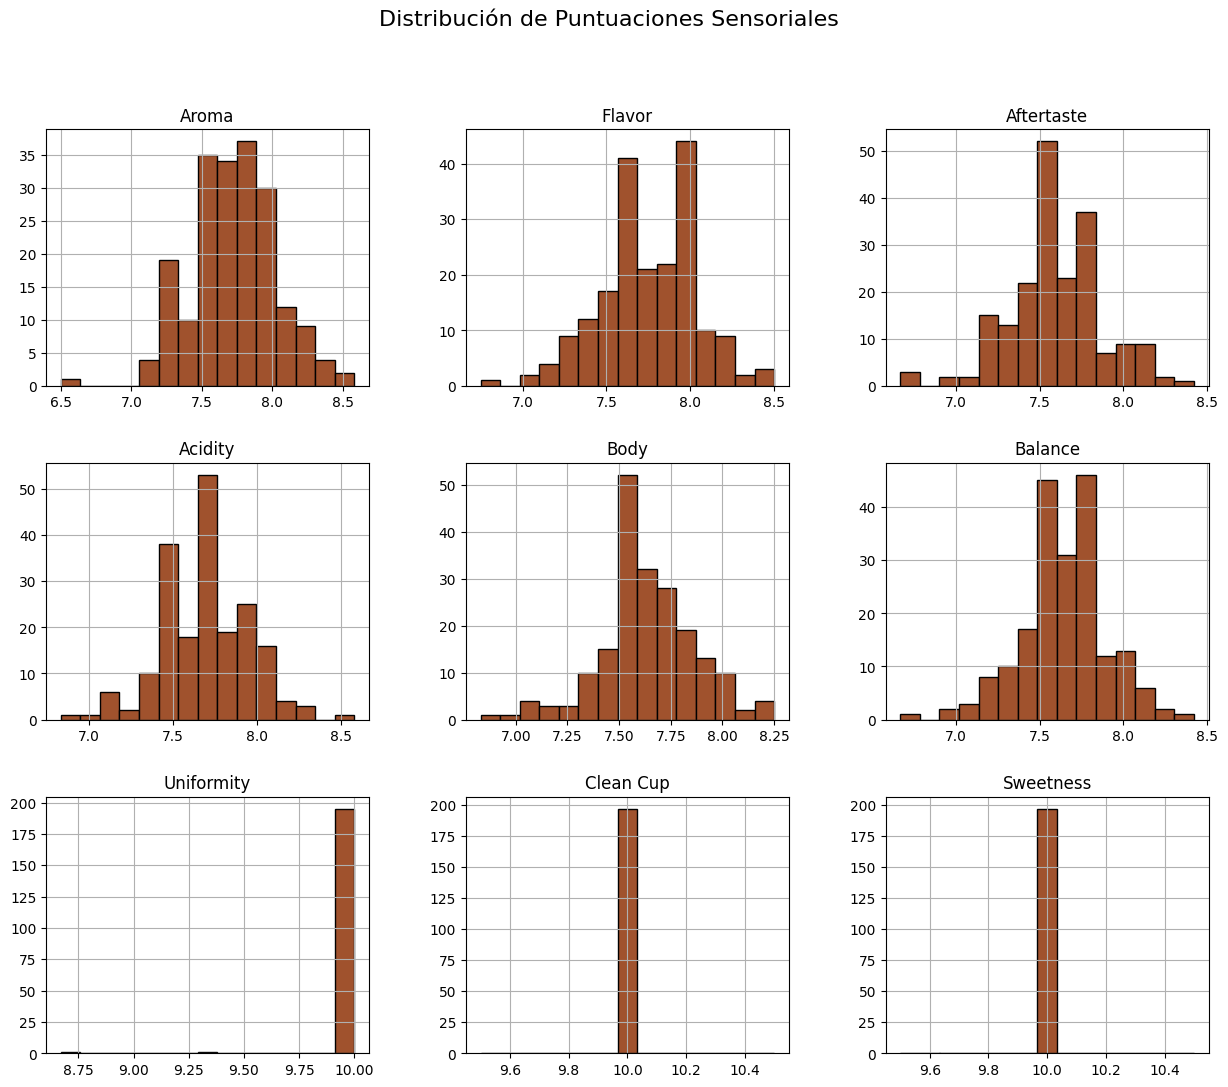

In [21]:
# Creamos una cuadrícula de gráficos
df[sensoriales].hist(bins=15, figsize=(15, 12), color='sienna', edgecolor='black')
plt.suptitle('Distribución de Puntuaciones Sensoriales', fontsize=16)
plt.show()


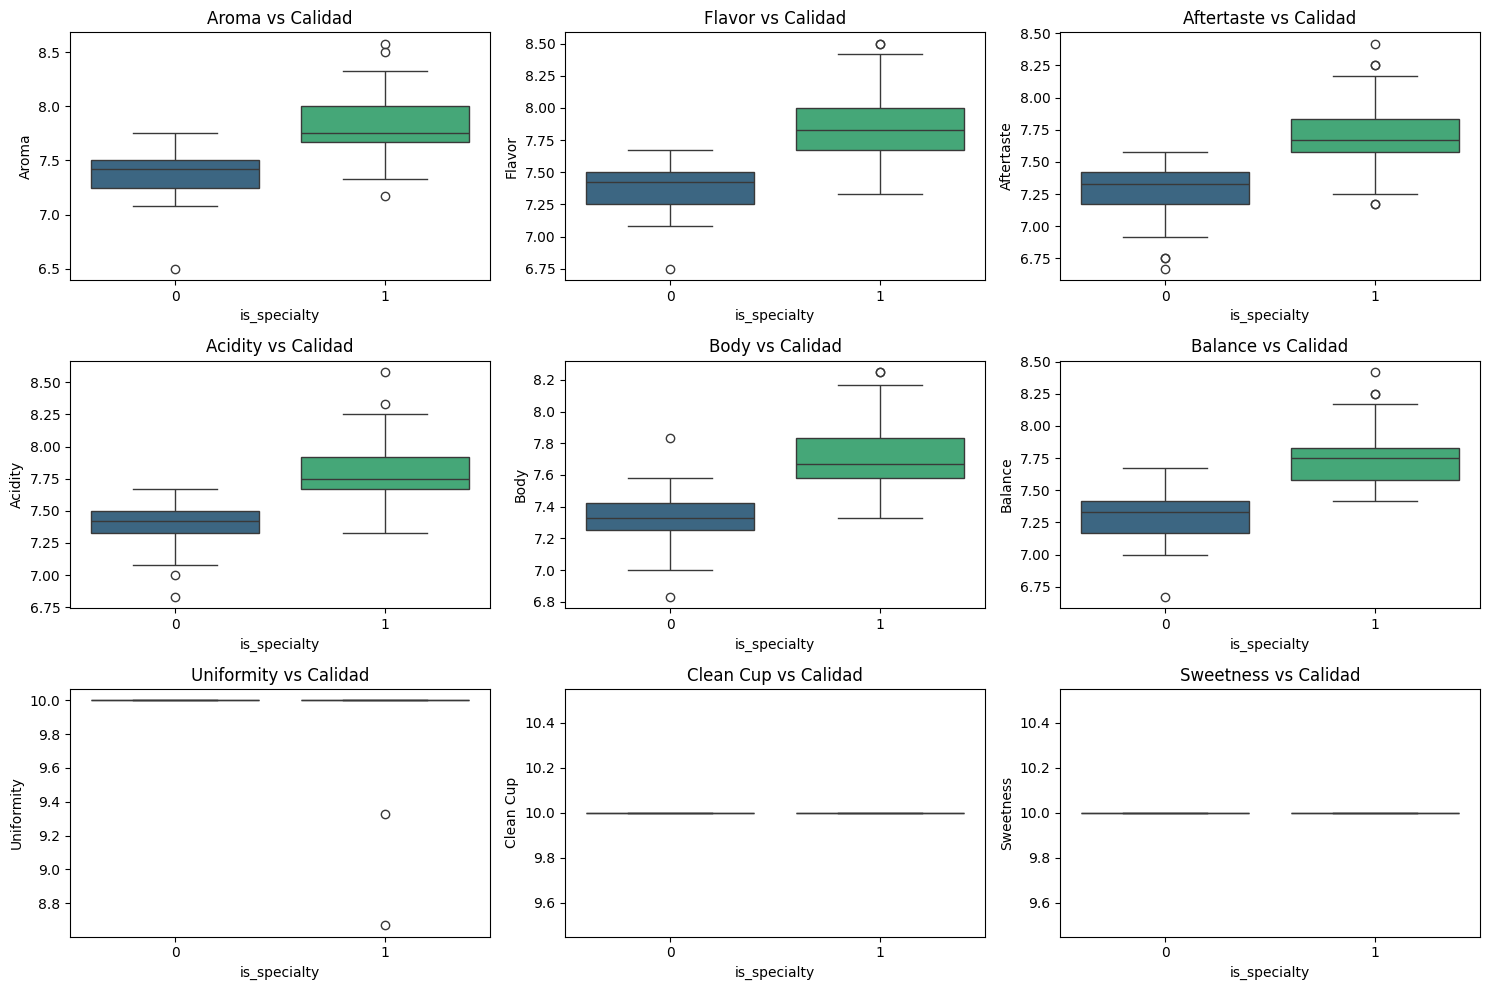

In [22]:
# Vamos a ver la diferencia entre clases para cada variable sensorial
plt.figure(figsize=(15, 10))

for i, col in enumerate(sensoriales):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='is_specialty', y=col, data=df, palette='viridis')
    plt.title(f'{col} vs Calidad')

plt.tight_layout()
plt.show()

---
## 🌍 BLOQUE 5 — Análisis de variables categóricas

**Variables categóricas:** Son las que tienen texto, como el país de origen, la variedad o el método de procesado.

**Objetivo:** Entender si el origen o el proceso del café influye en la calidad final.

EStos son solo ejemplo si ven necesarios pueden hacer sus propias preguntas y explorar.

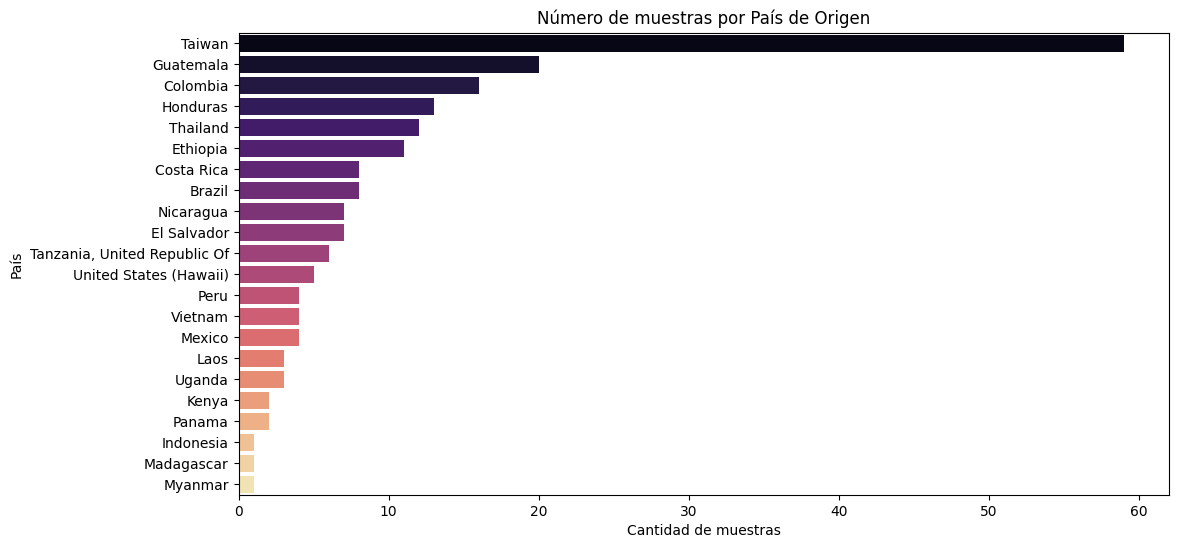

In [23]:
# ─── ANÁLISIS POR PAÍS DE ORIGEN ─────────────────────────────────────────────
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Country of Origin', order=df['Country of Origin'].value_counts().index, palette='magma')
plt.title('Número de muestras por País de Origen')
plt.xlabel('Cantidad de muestras')
plt.ylabel('País')
plt.show()

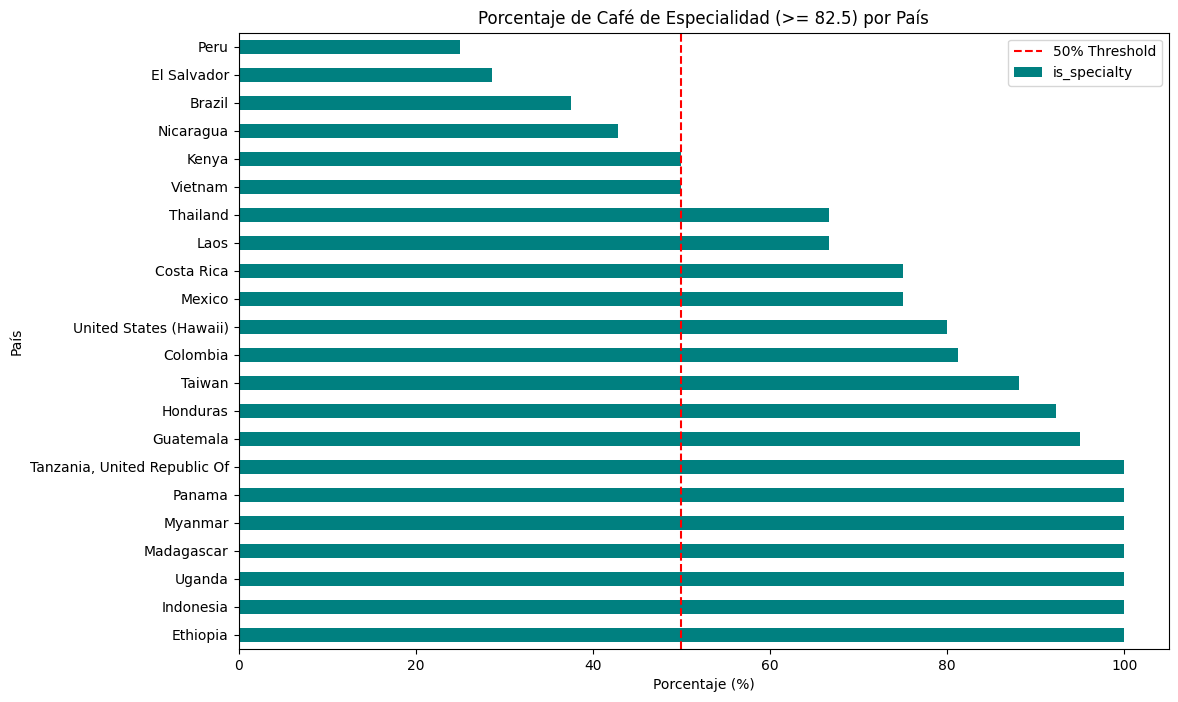

In [24]:
# ─── TASA DE SPECIALTY POR PAÍS ───────────────────────────────────────────────
# ¿Hay países donde una mayor proporción de su café es Specialty?
# ─── TASA DE SPECIALTY POR PAÍS ───────────────────────────────────────────────
# Calculamos el porcentaje de cafés Specialty (1) por cada país
paises_stats = df.groupby('Country of Origin')['is_specialty'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 8))
paises_stats.plot(kind='barh', color='teal')
plt.title('Porcentaje de Café de Especialidad (>= 82.5) por País')
plt.xlabel('Porcentaje (%)')
plt.ylabel('País')
plt.axvline(x=50, color='red', linestyle='--', label='50% Threshold') # Línea de referencia
plt.legend()
plt.show()


---
## 🔥 BLOQUE 6 — Matriz de correlación

**¿Qué es la correlación?**  
Mide cuánto se relacionan dos variables numéricas entre sí.  
- Correlación `+1` → cuando una sube, la otra también sube (relación perfecta positiva)  
- Correlación `-1` → cuando una sube, la otra baja (relación perfecta negativa)  
- Correlación `0` → no hay relación

**¿Para qué sirve en ML?**
- Identificar qué variables tienen más relación con el target
- Detectar variables muy correlacionadas entre sí (redundantes) — puede ser mejor eliminar una

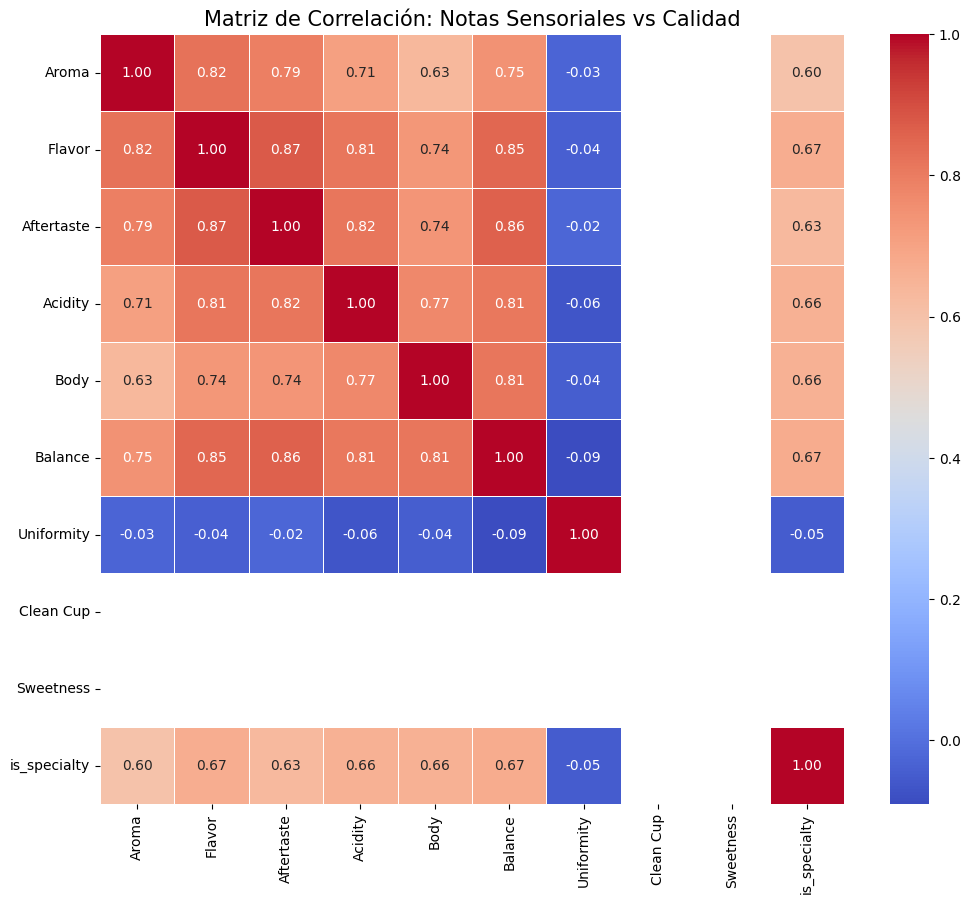

Correlación de los defectos con 'is_specialty':
Category One Defects   -0.016983
Category Two Defects   -0.211828
Quakers                -0.290246
is_specialty            1.000000
Name: is_specialty, dtype: float64


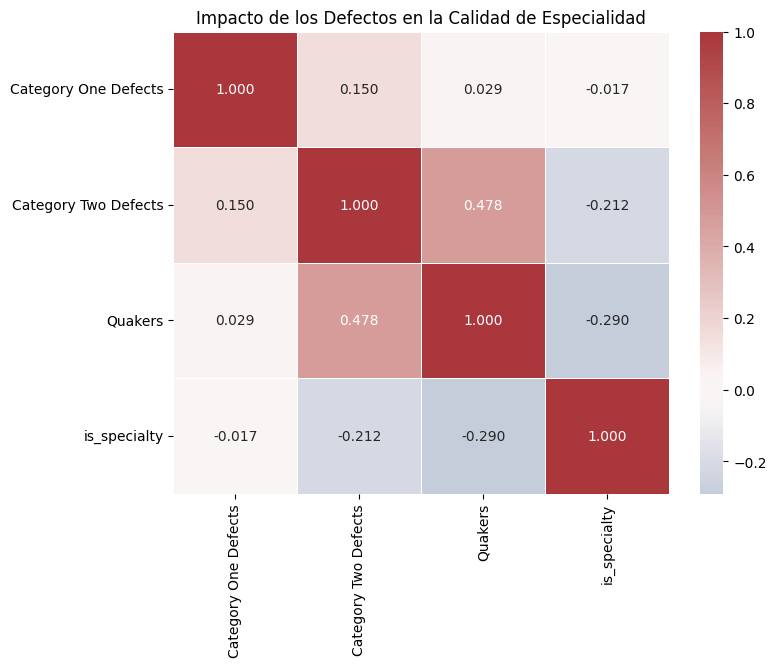

In [30]:
# ─── HEATMAP DE CORRELACIÓN ───────────────────────────────────────────────────
# Solo calculamos correlación entre columnas numéricas
# ─── HEATMAP DE CORRELACIÓN ───────────────────────────────────────────────────

cols_para_corr = sensoriales + ['is_specialty']
corr_matrix = df[cols_para_corr].corr()

# 2. Creamos el gráfico (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación: Notas Sensoriales vs Calidad', fontsize=15)
plt.show()

# Comprobamos la relación de los defectos con nuestra variable objetivo
defectos = ['Category One Defects', 'Category Two Defects', 'Quakers']
print("Correlación de los defectos con 'is_specialty':")
print(df[defectos + ['is_specialty']].corr()['is_specialty'])

# ─── HEATMAP DE DEFECTOS VS CALIDAD ───────────────────────────────────────────

# 1. Definimos las columnas que queremos comparar
cols_analisis = ['Category One Defects', 'Category Two Defects', 'Quakers', 'is_specialty']

# 2. Calculamos la matriz de correlación solo para estas variables
corr_defectos = df[cols_analisis].corr()

# 3. Creamos el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(corr_defectos, 
            annot=True,      # Muestra los números que me pasaste
            cmap='vlag',     # Un mapa de colores que resalta los negativos
            fmt=".3f",       # Tres decimales para mayor precisión
            center=0, 
            linewidths=0.5)

plt.title('Impacto de los Defectos en la Calidad de Especialidad')
plt.show()

---
## 🎯 BLOQUE 7 — Detección de Outliers

**¿Qué es un outlier?**  
Es un valor extremo que está muy alejado del resto.  
Por ejemplo: si todos los cafés tienen entre 7 y 9 puntos de aroma y hay uno con 1.5, ese es un outlier.

**¿Por qué importa?**  
Los outliers pueden distorsionar el modelo, haciéndolo aprender de casos excepcionales en lugar de la norma.

**Método IQR:**  
Se considera outlier cualquier valor fuera del rango `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`

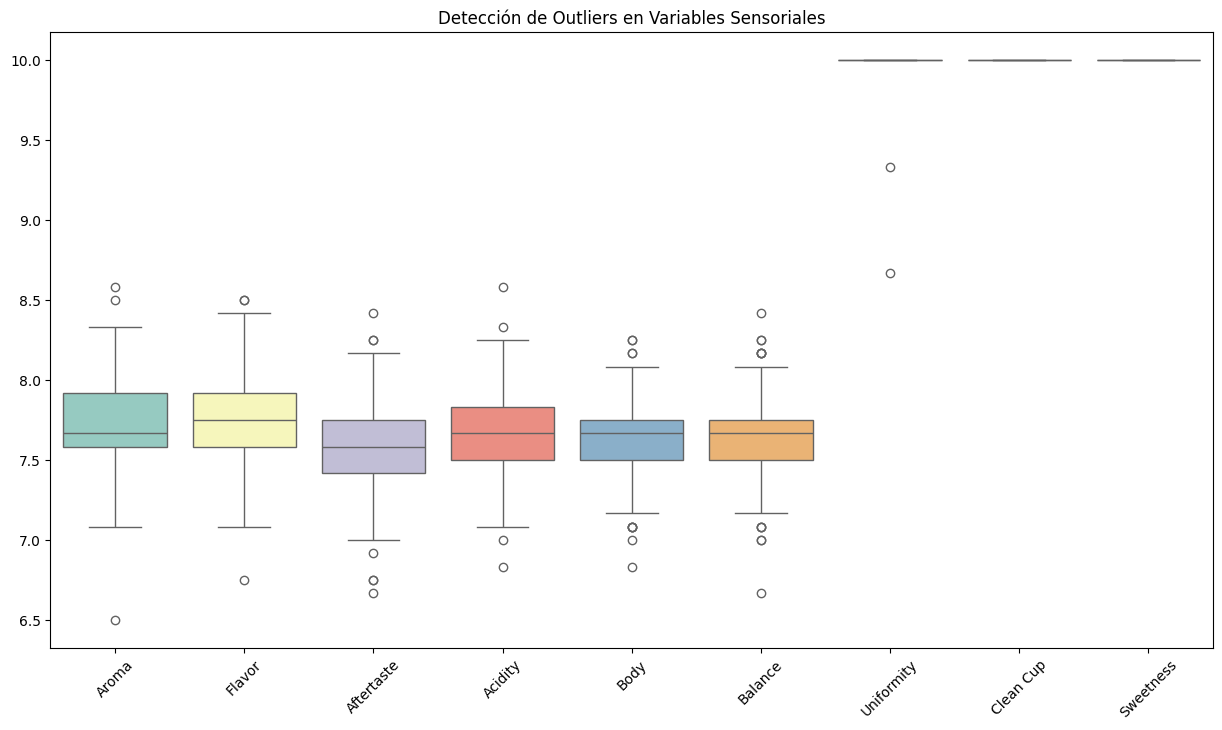

In [26]:
# ─── BOXPLOTS PARA DETECTAR OUTLIERS ─────────────────────────────────────────
# Los puntos fuera de los "bigotes" del boxplot son outliers
# ─── BOXPLOTS PARA DETECTAR OUTLIERS ─────────────────────────────────────────
# Vamos a ver todas las variables sensoriales juntas para identificar puntos negros (outliers)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[sensoriales], palette='Set3')
plt.title('Detección de Outliers en Variables Sensoriales')
plt.xticks(rotation=45)
plt.show()

In [27]:
# ─── CUANTIFICAR OUTLIERS CON EL MÉTODO IQR ───────────────────────────────────
#Para calcular si es correcto con las formulas vistas en clase (solo si ven outliers)
# ─── CUANTIFICAR OUTLIERS CON EL MÉTODO IQR ───────────────────────────────────

def count_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

print("Número de outliers por variable:")
for col in sensoriales:
    n_outliers = count_outliers(df, col)
    print(f"- {col}: {n_outliers}")

Número de outliers por variable:
- Aroma: 3
- Flavor: 3
- Aftertaste: 7
- Acidity: 4
- Body: 10
- Balance: 13
- Uniformity: 2
- Clean Cup: 0
- Sweetness: 0


---
## ✅ BLOQUE 8 — Conclusiones del EDA y próximos pasos

**Completa esta sección al terminar el análisis. Aquí van vuestras conclusiones reales.**

In [28]:
# ─── GUARDAR EL DATASET LIMPIO PARA EL SIGUIENTE NOTEBOOK ────────────────────
# Este CSV limpio será el punto de partida del notebook de preprocesamiento y modelado
# Debe esta en la carpeta processed
# ─── GUARDAR EL DATASET LIMPIO PARA EL SIGUIENTE NOTEBOOK ────────────────────
# Ruta definida según la estructura profesional del proyecto
ruta_salida = '../data/processed/coffee_cleaned.csv'

# Guardamos el CSV para usarlo en el notebook de preprocesamiento
df.to_csv(ruta_salida, index=False)

print(f"🎉 ¡Misión cumplida! Dataset guardado en: {ruta_salida}")

🎉 ¡Misión cumplida! Dataset guardado en: ../data/processed/coffee_cleaned.csv
